# Jordan Lake Spatiotemporal Simulation
ASV wind characterization simulation at the Jordan Lake mission domain.

Features:
- STGPKF Formulation
    - Generate Synthetic Data
    - Make estimates based upon existing measurements
- Ergodic Control
- Real-Time SOC-Based speed control
- Hyperparameter Estimation

In [1]:
# Import Packages
using Logging: global_logger
using TerminalLoggers: TerminalLogger
global_logger(TerminalLogger())

using ProgressLogging

using LinearAlgebra
using Random
using Statistics
using Plots
using LaTeXStrings
using Revise
using StaticArrays
using Interpolations
using LazySets
using SpatiotemporalGPs

In [2]:
# Import modules
include("../src/jordan_lake_domain.jl")
# include("../src/stgpkf.jl")
include("../src/kf.jl")
include("../src/ngpkf.jl")
include("../src/SyntheticData.jl")
include("../src/ergodic.jl")
include("../src/variograms.jl")
include("../src/SOC_Controller.jl")
include("../src/simulator_spatial.jl")
include("../src/simulator_ST.jl")
include("../src/Convex_bound_avoidance.jl")

┌ Warning: Replacing docs for Main.Variograms.hp_fit :: Tuple{Any} in module
│ Main.Variograms
└ @ Base.Docs docs/Docs.jl:243


Main.ConvexBoundAvoidance

# Synthetic Data

In [3]:
# Define simulation time-scale/steps
Δt = 2.5 # seconds
dt_min = Δt/(60) # convert ΔT from seconds to minutes
dt_hrs = Δt/(60*60) # convert ΔT from seconds to hours
T_begin = 9.0; # hours
T_end = 12.0; # hours 
ts_hrs = T_begin:dt_hrs:T_end # hours

9.0:0.0006944444444444445:12.0

In [17]:
# setup the spatial and temporal kernels
σt = 2.0   # m/s
σs = 1.0   # m/s
lt = 0.25*60.0  # minutes
ls = 0.75   # km

kt = Matern(3/2, σt, lt)
ks = Matern(1/2, σs, ls)

# determine the spatial step size
Δx = 0.10 # km

# create the spatial domain
xs = 0:Δx:1.4
ys = 0:Δx:6.5

grid_pts = vec([@SVector[x, y] for x in xs, y in ys]);

In [22]:
# generate synthetic data
synthetic_data = STGPKF.generate_spatiotemporal_process(xs, ys, Δt/60, (T_end-T_begin)*60, ks, kt);

In [21]:
synthetic_data.ts

0.0:0.0006944444444444445:2.9993055555555554

[ Info: Saved animation to /tmp/jl_zOhib09qt0.gif


Plots.AnimatedGif("/tmp/jl_zOhib09qt0.gif")
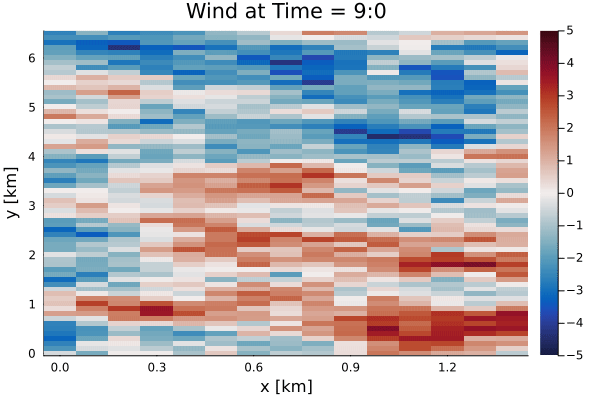

In [19]:
windfield = @animate for time_idx in 1:100:length(synthetic_data.ts)
    heatmap(synthetic_data.xs, synthetic_data.ys, synthetic_data.data[:, :, time_idx]', clims=(-5,5), cmap=:balance, plottype=:wx)
    title!("Wind at Time = $(Int(floor(ts[time_idx]))):$(Int(floor(mod(ts[time_idx],1)*60)))")
    xlabel!("x [km]")
    ylabel!("y [km]")
    # plot!(aspect_ratio=:equal)
end
gif(windfield)

[ Info: Saved animation to /tmp/jl_TGnExo34zK.gif


Plots.AnimatedGif("/tmp/jl_TGnExo34zK.gif")
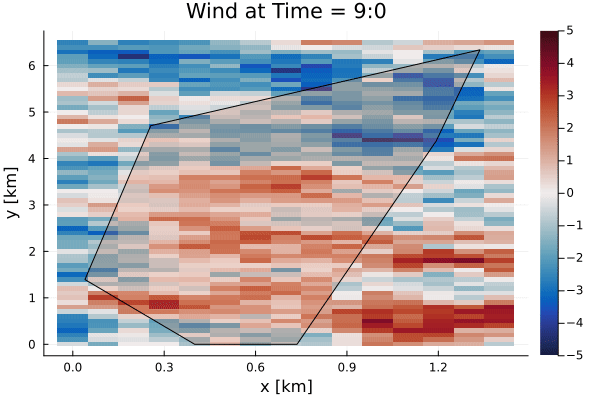

In [20]:
bounded_windfield = @animate for time_idx in 1:100:length(synthetic_data.ts)
    heatmap(synthetic_data.xs, synthetic_data.ys, synthetic_data.data[:, :, time_idx]', clims=(-5,5), cmap=:balance, plottype=:wx)
    polygon_vertices = hcat(JordanLakeDomain.convex_polygon.vertices, JordanLakeDomain.convex_polygon.vertices[:, 1])  # Close the polygon
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.2, label="")
    title!("Wind at Time = $(Int(floor(ts[time_idx]))):$(Int(floor(mod(ts[time_idx],1)*60)))")
    xlabel!("x [km]")
    ylabel!("y [km]")
    # plot!(aspect_ratio=:equal)
end
gif(bounded_windfield)

# Known Hyperparameter Simulation

## Controller Setup

In [ ]:
problem = STGPKFProblem(grid_pts, ks, kt, Δt)